# MiniBreakout Speedrun — DQN vs PPO vs GRPO

Train a network to **complete a tiny Atari-style game as fast as possible**, and
judge it by its completion time. We solve the same game three ways:

| algorithm | family | baseline for the advantage |
|-----------|--------|----------------------------|
| **DQN**  | value-based, off-policy | none — acts by `argmax Q`, learns from replay |
| **PPO**  | actor-critic, on-policy | a learned **value head** (GAE) |
| **GRPO** | policy-gradient, on-policy | the **mean of a group** of trajectories (no critic) |

DQN is the algorithm that first cleared Atari; PPO and GRPO are the ones used to
post-train LLMs. Everything here runs on CPU in a couple of minutes with no ROM,
no gym, no ALE — the game and all three agents are the reference modules that
live next to this notebook (`env.py`, `dqn.py`, `train.py`, `pg.py`).

In [1]:
import os, sys
# Make the atari-speedrun modules importable whether the kernel starts in the
# repo root or in this folder.
for cand in [os.getcwd(), os.path.join(os.getcwd(), "atari-speedrun")]:
    if os.path.exists(os.path.join(cand, "env.py")) and cand not in sys.path:
        sys.path.insert(0, cand)

import numpy as np
import matplotlib.pyplot as plt

import env
from env import MiniBreakout, MAX_STEPS
print("MiniBreakout loaded:", f"{env.W}x{env.H} grid, "
      f"paddle {env.PADDLE_W} wide, wall of {env.N_BRICKS} bricks, "
      f"budget {MAX_STEPS} steps")

MiniBreakout loaded: 5x5 grid, paddle 2 wide, wall of 6 bricks, budget 100 steps


## The game

A 5×5 grid Breakout. Bounce the ball off the paddle to chip away a wall of bricks;
the game is **completed** when the wall is cleared. Two rules make *speed* the
objective:

- **Any top-row contact chips one brick** ("chip the wall"), so the board is
  always clearable. (A literal grid Breakout is unwinnable: a pure-diagonal ball
  only ever visits one color of the checkerboard, so half the bricks are
  unreachable.)
- **A miss is fatal.** Winning therefore requires a whole *chain* of catches —
  the survival skill a random policy lacks.

Here is the starting frame (`=` bricks, `o` ball, `#` paddle):

In [2]:
game = MiniBreakout(seed=0)
game.reset()
print(game.render())
print("\nobservation (6 numbers, normalized):", np.round(game._obs(), 2))
print("[ball x, ball y, vx, vy, paddle x, bricks-left]")

+-----+
|=====|
|     |
|     |
|  o  |
| ##  |
+-----+

observation (6 numbers, normalized): [0.5  0.75 0.   0.   0.33 1.  ]
[ball x, ball y, vx, vy, paddle x, bricks-left]


### The metric: time-to-complete

Steps taken to clear the wall, with a **did-not-finish counted as the full step
budget** (`MAX_STEPS`). This is what makes "lower = faster" honest — a policy
that dies at step 12 scores 100, not 12. The physical floor is ~43 steps
(6 bricks × one ball round-trip each); no policy can beat it, only reach it.

A uniform-random policy almost never survives long enough to finish:

In [3]:
def random_baseline(n=2000):
    e = MiniBreakout(seed=7); rng = np.random.default_rng(7)
    wins, times = 0, []
    for _ in range(n):
        e.reset(); done, info = False, {"won": False, "steps": 0}
        while not done:
            _, _, done, info = e.step(int(rng.integers(0, 3)))
        wins += info["won"]
        times.append(info["steps"] if info["won"] else MAX_STEPS)
    return wins / n, float(np.mean(times))

rand_completion, rand_time = random_baseline()
print(f"random policy: {rand_completion:.1%} completion, "
      f"{rand_time:.1f} mean steps-to-finish")

random policy: 4.2% completion, 97.6 mean steps-to-finish


## 1. DQN — value-based, off-policy

Textbook DQN (Mnih et al. 2015): a replay buffer, a target network, ε-greedy
exploration, and the Bellman target `y = r + γ·maxₐ' Q_target(s',a')` with
terminal transitions **not** bootstrapped. We keep the full eval history so we
can plot the learning curve.

In [4]:
from train import train as train_dqn, evaluate as evaluate_dqn

dqn_net, dqn_hist = train_dqn(steps=10000, eval_every=1000, seed=0, log=False)
c, t, w = evaluate_dqn(dqn_net, n_episodes=1000)
print(f"DQN final: {c:.1%} completion, {t:.1f} mean time, {w:.1f}-step speedrun")

DQN final: 100.0% completion, 43.0 mean time, 43.0-step speedrun


## 2. PPO — actor-critic, on-policy

Collect a rollout with the current policy, estimate advantages with **GAE**
against a learned **value head**, and take a few epochs of the **clipped
surrogate** update (plus a value loss and an entropy bonus).

In [5]:
from pg import train_ppo, evaluate_policy

ppo_net, ppo_hist = train_ppo(iters=50, eval_every=5, seed=0, log=False)
c, t, w = evaluate_policy(ppo_net, n_episodes=1000)
print(f"PPO final: {c:.1%} completion, {t:.1f} mean time, {w:.1f}-step speedrun")

PPO final: 100.0% completion, 43.0 mean time, 43.0-step speedrun


## 3. GRPO — critic-free, group-relative

No value network. For each start state, sample a **group** of trajectories and
use each one's return **standardized within the group** as its advantage,
broadcast to every timestep. This is exactly the LLM GRPO recipe (a group of
completions per prompt), with "prompt" = initial game state — `env.snapshot()` /
`restore()` make the whole group start from an identical state so the only
variance is the sampled actions.

In [6]:
from pg import train_grpo

grpo_net, grpo_hist = train_grpo(iters=50, eval_every=5, seed=0, log=False)
c, t, w = evaluate_policy(grpo_net, n_episodes=1000)
print(f"GRPO final: {c:.1%} completion, {t:.1f} mean time, {w:.1f}-step speedrun")

GRPO final: 100.0% completion, 43.0 mean time, 43.0-step speedrun


## Results

All three reach the physical speed limit. The table and the learning curves
below tell the story; the x-axis is *normalized training progress* because the
three methods count training in different units (DQN gradient steps vs PPO/GRPO
rollout iterations).

In [7]:
runs = {"DQN": dqn_hist, "PPO": ppo_hist, "GRPO": grpo_hist}

print(f"{'algorithm':<14}{'completion':>12}{'time-to-finish':>16}{'speedrun':>10}")
print("-" * 52)
print(f"{'random':<14}{rand_completion:>11.1%}{rand_time:>16.1f}{'--':>10}")
for name, h in runs.items():
    f = h[-1]
    print(f"{name:<14}{f['completion']:>11.1%}{f['mean_time']:>16.1f}"
          f"{f['win_time']:>10.1f}")

algorithm       completion  time-to-finish  speedrun
----------------------------------------------------
random               4.2%            97.6        --
DQN                100.0%            43.0      43.0
PPO                100.0%            43.0      43.0
GRPO               100.0%            43.0      43.0


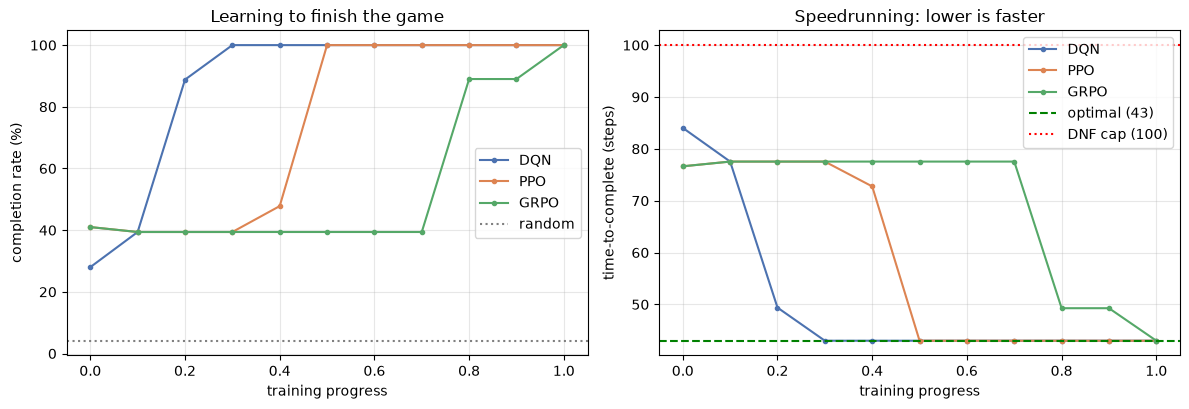

In [8]:
def progress(h):
    last = h[-1]["step"] or 1
    return [x["step"] / last for x in h]

colors = {"DQN": "#4C72B0", "PPO": "#DD8452", "GRPO": "#55A868"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

for name, h in runs.items():
    ax1.plot(progress(h), [x["completion"] * 100 for x in h],
             marker="o", ms=3, color=colors[name], label=name)
ax1.axhline(rand_completion * 100, ls=":", c="gray", label="random")
ax1.set_xlabel("training progress"); ax1.set_ylabel("completion rate (%)")
ax1.set_title("Learning to finish the game"); ax1.legend(); ax1.grid(alpha=.3)

for name, h in runs.items():
    ax2.plot(progress(h), [x["mean_time"] for x in h],
             marker="o", ms=3, color=colors[name], label=name)
ax2.axhline(43, ls="--", c="green", label="optimal (43)")
ax2.axhline(MAX_STEPS, ls=":", c="red", label="DNF cap (100)")
ax2.set_xlabel("training progress"); ax2.set_ylabel("time-to-complete (steps)")
ax2.set_title("Speedrunning: lower is faster"); ax2.legend(); ax2.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Watch a trained agent speedrun

Greedy rollout from the trained PPO policy — the wall depletes as the ball is
kept alive and bounced into the top row.

In [9]:
import torch

def render_frames(policy, seed=123):
    e = MiniBreakout(seed=seed); obs = e.reset(); frames = [e.render()]
    done, info = False, {"won": False}
    while not done:
        a = int(policy.logits(torch.tensor(obs).unsqueeze(0)).argmax())
        obs, _, done, info = e.step(a); frames.append(e.render())
    return frames, info

frames, info = render_frames(ppo_net)
print(f"result: {'WON' if info['won'] else 'DNF'} in {info['steps']} steps\n")
for label, fr in [("start", frames[0]), ("mid", frames[len(frames)//2]),
                  ("end", frames[-1])]:
    print(f"--- {label} ---"); print(fr)

result: WON in 43 steps

--- start ---
+-----+
|=====|
|     |
|     |
|  o  |
| ##  |
+-----+
--- mid ---
+-----+
|===  |
|     |
|     |
|    o|
|   ##|
+-----+
--- end ---
+-----+
| o   |
|     |
|     |
|     |
|##   |
+-----+


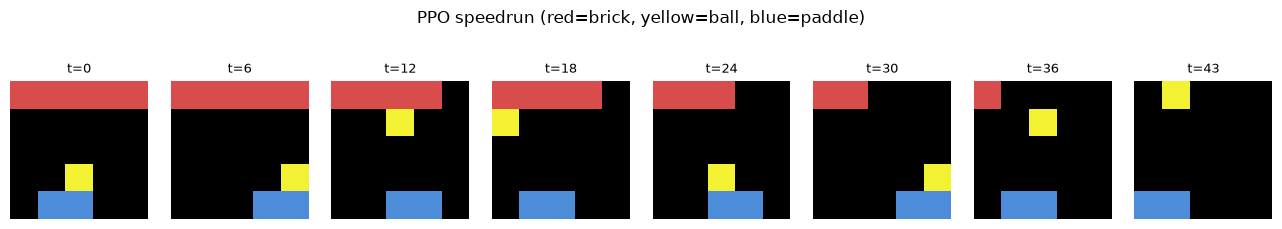

In [10]:
# Same rollout as a strip of pixel frames.
def to_image(frame_str):
    rows = [r[1:-1] for r in frame_str.splitlines()[1:-1]]  # strip borders
    img = np.zeros((len(rows), len(rows[0]), 3))
    for y, row in enumerate(rows):
        for x, ch in enumerate(row):
            if ch == "=": img[y, x] = [0.85, 0.30, 0.30]   # brick
            elif ch == "o": img[y, x] = [0.95, 0.95, 0.20]  # ball
            elif ch == "#": img[y, x] = [0.30, 0.55, 0.85]  # paddle
    return img

picks = np.linspace(0, len(frames) - 1, 8).astype(int)
fig, axes = plt.subplots(1, len(picks), figsize=(13, 2))
for ax, i in zip(axes, picks):
    ax.imshow(to_image(frames[i]), interpolation="nearest")
    ax.set_title(f"t={i}", fontsize=9); ax.axis("off")
plt.suptitle("PPO speedrun (red=brick, yellow=ball, blue=paddle)", y=1.12)
plt.tight_layout(); plt.show()

## Takeaways

- **All three algorithms reach the ~43-step speed limit** from a ~4% random
  baseline — the game is small, so the interesting part is *how* each defines
  its advantage, not the final score.
- **DQN** is sample-efficient (it replays every transition many times) but needs
  the target-network machinery to stay stable.
- **PPO** trains a critic as its baseline; **GRPO** throws the critic away and
  uses a group mean instead — cheaper per design, but it pays by sampling a
  whole group per start state (highest wall-clock here) and can wobble once the
  group collapses to identical trajectories (zero-variance advantage).
- The same `(1 − done)` terminal-bootstrap discipline shows up in **both** DQN's
  Bellman target and PPO's GAE — forget it in either place and the agent chases
  the value of a future that isn't reachable.

See the reference modules (`dqn.py`, `pg.py`, `env.py`) and the `README.md` in
this folder for the full implementations, gotchas, and interview follow-ups.